In [153]:
import numpy as np
import xml.etree.ElementTree as ET
import spiceypy as spice
import matplotlib.pyplot as plt
from datetime import datetime, timezone
from dateutil import parser
import grss
import pandas as pd

In [154]:
# Constants
MU_SUN = 1.327e11 # km3/s2
AU = 1.496e+8 # km

# npice Kernels
spice.furnsh("naif0012.tls")
spice.furnsh("de440.bsp")

In [155]:
pdc25 = ET.parse("2024pdc25.xml")
root = pdc25.getroot()

# observation labels
observations = []
times = []
earth_states = []

labels = np.array(["ra", "dec", "rmsRA", "rmsDec", "mag", "rmsMag"])

# parse through tree, add only float values because others are constant
for obs in root.findall("optical"):
    time = obs.findtext("obsTime")
    earth_state, lt = spice.spkezr("EARTH", spice.str2et(time), "J2000", "NONE", "SUN")
    
    data = np.array([
        np.radians(float(obs.findtext("ra"))),
        np.radians(float(obs.findtext("dec"))),
        float(obs.findtext("rmsRA")),
        float(obs.findtext("rmsDec")),
        float(obs.findtext("mag")),
        float(obs.findtext("rmsMag")),
    ])
    
    earth_states.append(np.array(earth_state))
    times.append(np.array([time, parser.isoparse(time).timestamp()]))
    observations.append(data)
    
earth_states = np.array(earth_states)
times = np.array(times)
observations = np.array(observations)

Question 2: Initial Orbit Determination

In [156]:
# IOD was completed using Find_Orb. 
# Initially, my own Gauss + Gibbs methods were used for IOD but they were getting highly inconsistent results that did not line up with the example solution

# current date is 2460522.6 JDT, perihelion is 2460441.09554 JDT
# convert to MJD and you get 60522 and 60440.59554

# Find Orb init_sol
init_sol_find_orb = {'t': 60522.1, # MJD TDB
            'e': .3905426, 
            'q': 1.00540086, # AU
            'tp': 60440.59554, # MJD TDB
            'om': 214.44311 / 180 * np.pi, # rad
            'w': 359.94542 / 180 * np.pi, # Rad
            'i': 10.68657 / 180 * np.pi, #Rad
            } # MJD TDB

# Eggl init_sol
init_sol_eggl = {'t': 60522, # MJD TDB
            'e': 0.3906575,
            'q': 1.00537975, # AU
            'tp': 60440.598182003385, #60446.77528505558, # MJD TDB
            'om': 214.42379 / 180 * np.pi, # [rad]
            'w': 359.96368 / 180 * np.pi, # [rad]
            'i': 10.68883 / 180 * np.pi}

init_cov = np.identity(6) * 0.1

Question 3: Orbit Determination using GRSS

In [157]:
body_id = 'SYNTH'
add_gaia_obx = False
t_min_tdb = None
t_max_tdb = None
debias_lowres = False
deweight = True
eliminate = False
num_obs_per_night = 4
verbose = True

optical_obs_file = "2024PDC25.xml"

obs_df = grss.fit.get_optical_obs(body_id, optical_obs_file, t_min_tdb, t_max_tdb, debias_lowres, deweight, eliminate, num_obs_per_night, verbose)

pd.set_option('display.max_columns', None)

Read in 98 observations from the file.
	Filtered to 98 observations that satisfy the time range and accepted observatory constraints.
Applying Eggl et al. (2020) debiasing scheme to the observations.
	Unknown star catalog: UNK
	No debiasing needed for 0 observations.
	Debiased 0 observations.
	No bias information for 98 observations.
Applying Vereš et al. (2017) weighting scheme to the observations.
	Using 0 CCD observations with station-specific weight rules.
Applying sqrt(N/4) deweighting scheme.
	Deweighted 98 observations.


In [158]:
# taken from example problem
de_kernel = 440
nongrav_info = {
    'a1': 0.0,
    'a2': 0.0,
    'a3': 0.0,
    'alpha': 1.0,
    'k': 0.0,
    'm': 2.0,
    'n': 0.0,
    'r0_au': 1.0,
    'radius': 0.0,
}

init_sol = init_sol_find_orb

n_iter_max = 20
fit_sim = grss.fit.FitSimulation(init_sol, obs_df, init_cov, n_iter_max=n_iter_max, de_kernel=de_kernel, nongrav_info=nongrav_info)
fit_sim.reject_outliers = True
fit_sim.analytic_partials = True
fit_sim.reject_criteria = [2.0, 1.8]

In [159]:
fit_sim.filter_lsq()

Iteration		Unweighted RMS		Weighted RMS 		Chi-squared		Reduced Chi-squared
1			 28.243			 5.706			 6381.319			 33.586
2			 0.008			 0.002			 0.000			 0.000
Converged without rejecting outliers. Starting outlier rejection now...
3			 0.004			 0.001			 0.000			 0.000
Converged after rejecting outliers. Rejected 0 out of 98 optical observations.


In [160]:
fit_sim.print_summary()

Summary of the orbit fit calculations after postfit pass:
RMS unweighted: 0.003622396967137021
RMS weighted: 0.000731809564610019
chi-squared: 0.00010496686681552228
reduced chi-squared: 5.524571937659067e-07
square root of reduced chi-squared: 0.0007432746422190836
--------------------------------------------------------------
Solution Time: MJD 60522.100 TDB = 2024-07-31 02:24:00.000 TDB
Solution Observation Arc: 56.10 days (0.15 years)
--------------------------------------------------------------
Fitted Variable		Initial Value			Uncertainty			Fitted Value			Uncertainty			Change				Change (sigma)
e			3.90542600000e-01		3.16227766017e-01		3.90657596069e-01		3.99772902717e-04		+1.14996069258e-04		+0.288
q			1.00540086000e+00		3.16227766017e-01		1.00537977889e+00		3.71591743832e-05		-2.10811145211e-05		-0.567
tp			6.04405955400e+04		3.16227766017e-01		6.04405981854e+04		1.26725834406e-02		+2.64539185446e-03		+0.209
om			2.14443110000e+02		1.81185163576e+01		2.14423792313e+02		1.1723506

In [161]:
def print_mean_cov(mean, cov):
    labels = ["e", "q", "tp", "raan", "argp", "i"]
    print(f"e = {mean[0]}")
    print(f"q = {mean[1]}")
    print(f"tp = {mean[2]} MJD")
    print(f"raan = {mean[3] * 180 / np.pi} deg")
    print(f"argp = {mean[4] * 180 / np.pi} deg")
    print(f"i = {mean[5] * 180 / np.pi} deg")
    
    cov_df = pd.DataFrame(cov, index=labels, columns=labels)
    pd.set_option("display.precision", 6)
    pd.set_option("display.width", 120)
    print("Covariance matrix:")
    print(cov_df)

mean_0 = np.array(list(init_sol.values())[1:])
cov_0 = init_cov
mean_f = np.array(list(fit_sim.x_nom.values()))
cov_f = np.array(fit_sim.covariance)

In [162]:
print_mean_cov(mean_0, cov_0)

e = 0.3905426
q = 1.00540086
tp = 60440.59554 MJD
raan = 214.44311 deg
argp = 359.94542 deg
i = 10.68657 deg
Covariance matrix:
        e    q   tp  raan  argp    i
e     0.1  0.0  0.0   0.0   0.0  0.0
q     0.0  0.1  0.0   0.0   0.0  0.0
tp    0.0  0.0  0.1   0.0   0.0  0.0
raan  0.0  0.0  0.0   0.1   0.0  0.0
argp  0.0  0.0  0.0   0.0   0.1  0.0
i     0.0  0.0  0.0   0.0   0.0  0.1


In [163]:
print_mean_cov(mean_f, cov_f)

e = 0.3906575960692584
q = 1.0053797788854788
tp = 60440.59818539186 MJD
raan = 214.4237923133143 deg
argp = 359.96369184425714 deg
i = 10.688832731877653 deg
Covariance matrix:
                 e             q            tp          raan          argp             i
e     1.598184e-07  1.467008e-08  5.031714e-06 -8.137344e-08  1.116577e-07  3.724016e-08
q     1.467008e-08  1.380804e-09  4.702415e-07 -7.557769e-09  1.051612e-08  3.396263e-09
tp    5.031714e-06  4.702415e-07  1.605944e-04 -2.584090e-06  3.583839e-06  1.166356e-06
raan -8.137344e-08 -7.557769e-09 -2.584090e-06  4.186680e-08 -5.775010e-08 -1.887463e-08
argp  1.116577e-07  1.051612e-08  3.583839e-06 -5.775010e-08  8.035777e-08  2.580197e-08
i     3.724016e-08  3.396263e-09  1.166356e-06 -1.887463e-08  2.580197e-08  8.700687e-09


Question 4: Propagation

In [164]:
N = 1000

de_kernel = 440
de_kernel_path = grss.utils.default_kernel_path

t0 = fit_sim.t_sol # July 31, 2024
tf = 66633 # April 24, 2041
t_eval = np.arange(t0, tf+1, 1)

ng_params = grss.prop.NongravParameters()
ng_params.a1 = 0.0
ng_params.a2 = 0.0
ng_params.a3 = 0.0
ng_params.alpha = 1.0
ng_params.k = 0.0
ng_params.m = 2.0
ng_params.n = 0.0
ng_params.r0_au = 1.0
samples = np.random.multivariate_normal(mean_f, cov_f, N)

eval_apparent_state = False
t_eval_utc = False
converged_light_time = False
prop_sim = grss.prop.PropSimulation("PDC25 Covariance Propagation", t0, de_kernel, de_kernel_path)
prop_sim.set_integration_parameters(tf, t_eval, t_eval_utc, eval_apparent_state, converged_light_time)

pdc_25 = grss.libgrss.cometary_to_cartesian(t0, mean_f)

integ_body = grss.prop.IntegBody("Orbit Mean", t0, 0, 0, pdc_25[0:3], pdc_25[3:6], ng_params)
prop_sim.add_integ_body(integ_body)

for i, sample in enumerate(samples):
    integ_body = grss.prop.IntegBody(f"sample_{i}", t0, 0, 0, sample, ng_params)
    prop_sim.add_integ_body(integ_body)

prop_sim.integrate()

In [167]:
arr = np.array(prop_sim.xIntegEval)

samples_f = []
for i in range(N):
    sample = arr[-1,0+6*i:6+6*i]
    cometary = grss.libgrss.cartesian_to_cometary(tf, sample)
    samples_f.append(cometary)

samples_tf = np.array(samples_f)
mean_tf = np.mean(samples_tf, axis = 0)
cov_tf = np.cov(samples_tf, rowvar = False)
print_mean_cov(mean_tf, cov_tf)


e = 0.38073046306337005
q = 0.9993885411547433
tp = 66634.50638099258 MJD
raan = 337.08064671293505 deg
argp = 235.89169207309723 deg
i = 15.752734194807378 deg
Covariance matrix:
                 e             q         tp      raan      argp             i
e     4.257145e-07 -9.324258e-08   0.000641 -0.000018  0.000018 -7.209429e-07
q    -9.324258e-08  1.062900e-07   0.000293  0.000021 -0.000021  8.562392e-07
tp    6.412531e-04  2.932052e-04  44.167584  0.052240 -0.024389  1.639500e-03
raan -1.769986e-05  2.114299e-05   0.052240  0.004615 -0.004611  1.886644e-04
argp  1.819558e-05 -2.110277e-05  -0.024389 -0.004611  0.004625 -1.888129e-04
i    -7.209429e-07  8.562392e-07   0.001640  0.000189 -0.000189  7.758107e-06


Average Monte-Carlo Distance: 0.10659092531797397 au
Minimum Monte-Carlo Distance: 0.0023140103226724925 au


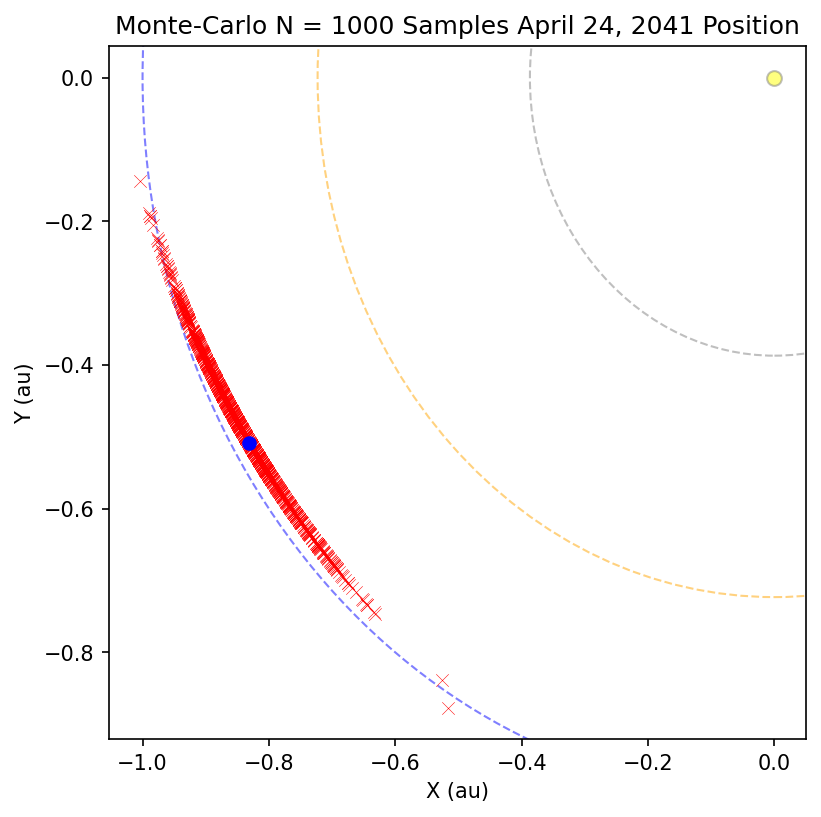

In [168]:
# arr = np.array(prop_sim.xIntegEval[-1]).reshape((-1, 6))
plt.figure(figsize = (6, 6), dpi = 150)
prop_sim.map_ephemeris()

axs = plt.gca()
grss.prop.plot_solar_system(axs, xy_plane=True, alpha = 0.5)
earth_state = prop_sim.get_spiceBody_state(tf, "Earth")

dists = []
for i in range(N+1):
    axs.scatter(arr[-1,0+6*i], arr[-1,1+6*i], marker ='x', color = 'r', lw = 0.25)
    dist = np.linalg.norm(arr[-1,0+6*i:3+6*i] - earth_state[0:3])
    dists.append(dist)
dists = np.array(dists)

plt.title(f"Monte-Carlo N = {N} Samples April 24, 2041 Position")
plt.xlabel("X (au)")
plt.ylabel("Y (au)")

plt.scatter(earth_state[0], earth_state[1], color = 'blue', marker = 'o')
print(f"Average Monte-Carlo Distance: {np.mean(dists)} au")
print(f"Minimum Monte-Carlo Distance: {np.min(dists)} au")

Average Monte-Carlo Distance: 0.10659092531797397 au
Minimum Monte-Carlo Distance: 0.0023140103226724925 au


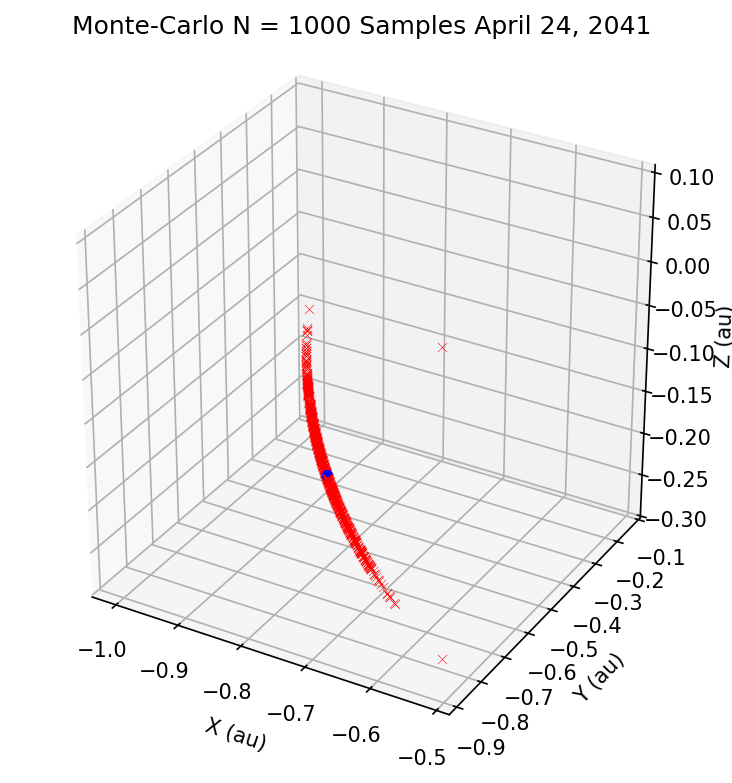

In [171]:
from mpl_toolkits.mplot3d import Axes3D

plt.figure(figsize=(6, 6), dpi=150)
ax = plt.axes(projection='3d')

earth_state = prop_sim.get_spiceBody_state(tf, "Earth")

dists = []
for i in range(N+1):
    x = arr[-1, 0 + 6*i]
    y = arr[-1, 1 + 6*i]
    z = arr[-1, 2 + 6*i]
    
    ax.scatter(x, y, z, marker='x', color='r', lw=0.25)
    
    dist = np.linalg.norm(arr[-1, 0+6*i:3+6*i] - earth_state[0:3])
    dists.append(dist)

dists = np.array(dists)

# Earth
ax.scatter(
    earth_state[0],
    earth_state[1],
    earth_state[2],
    color='blue',
    marker='o'
)

ax.set_title(f"Monte-Carlo N = {N} Samples April 24, 2041")
ax.set_xlabel("X (au)")
ax.set_ylabel("Y (au)")
ax.set_zlabel("Z (au)")

# make axes equal scale (important for space plots)
ax.set_box_aspect([1,1,1])

print(f"Average Monte-Carlo Distance: {np.mean(dists)} au")
print(f"Minimum Monte-Carlo Distance: {np.min(dists)} au")